# 1.1 Thinking in JAX

JAX looks like NumPy but behaves like a compiler. Code written for JAX can be
transformed: differentiated (`jax.grad`), compiled for speed (`jax.jit`), and applied
across whole ensembles at once (`jax.vmap`). Those transformations are what the rest of
this book is built on — but they come with rules. This chapter is organized around one
question: **what breaks when you port your NumPy code to JAX, and why?** Every
restriction has the same origin: for JAX to transform your code, it must be able to
treat it as a mathematical function, not as a sequence of instructions with side
effects.

```{admonition} Learning goals
:class: tip
- Explain what *tracing* is and why JAX requires functions to be *pure*
- Port a small NumPy computation to JAX, fixing in-place assignment and `if` statements
- Use `jax.jit`, `jax.vmap`, parameter dictionaries (pytrees), and explicit random keys
- Recognize the failure modes collected in the [gotchas appendix](../appendix/jax-gotchas.md)
```

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

## From NumPy to `jax.numpy`

`jax.numpy` (imported as `jnp` by convention) reproduces most of NumPy. Array creation,
arithmetic, reductions, and linear algebra carry over unchanged. Here is an area-weighted
global mean of a zonal temperature profile, written identically in both libraries:

In [2]:
import numpy as np

lat = np.linspace(-89, 89, 90)                      # latitude, degrees
T_np = 30.0 * np.cos(np.deg2rad(lat)) - 10.0        # a made-up temperature profile, degC

weights = np.cos(np.deg2rad(lat))
print("NumPy:", np.sum(T_np * weights) / np.sum(weights))

T = jnp.asarray(T_np)
w = jnp.cos(jnp.deg2rad(jnp.asarray(lat)))
print("JAX:  ", jnp.sum(T * w) / jnp.sum(w))

NumPy: 13.560748690332739
JAX:   13.560748690332748


## The first thing that breaks: assignment

JAX arrays are *immutable* — they cannot be modified after creation. Assigning into an
array, a habit from NumPy and Fortran alike, raises an error:

In [3]:
try:
    T[0] = -40.0
except TypeError as e:
    print("TypeError:", e)

TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html


The replacement is the `.at[...].set(...)` syntax, which returns a **new** array with
the requested element changed:

In [4]:
T_updated = T.at[0].set(-40.0)
print("original :", T[0])
print("updated  :", T_updated[0])

original : -9.476427806881492
updated  : -40.0


Immutability feels wasteful, but the compiler removes the cost: inside a compiled
function, an update whose input is not reused is performed in place. What immutability
buys is a guarantee — no function can silently modify data another function depends on.
That guarantee is what makes automatic differentiation of large programs tractable.

## Pure functions and tracing

A **pure function** returns outputs that depend only on its explicit inputs, and does
nothing else — no printing, no writing to globals, no modifying its arguments. JAX
requires purity because of how its transformations work: they run your function once
with abstract *tracer* values in place of real arrays, record every mathematical
operation encountered, and then transform the recorded computation. Anything that is
not a recorded operation — such as a `print` — happens once, during tracing, and never
again:

In [5]:
@jax.jit
def absorbed_shortwave(albedo):
    print("  (tracing now — this line runs only when JAX records the function)")
    return 340.0 * (1.0 - albedo)

print("first call: ", absorbed_shortwave(0.3))
print("second call:", absorbed_shortwave(0.32))   # no print: the recording is reused

  (tracing now — this line runs only when JAX records the function)
first call:  237.99999999999997
second call: 231.2


The first call traces and compiles; the second reuses the compiled code. This is
also why side effects inside model code silently disappear: they are not part of the
recorded mathematics. For printing *inside* compiled code, use `jax.debug.print`
(Chapter 3.5 uses it to hunt down invalid values).

## `jit`: compile once, run fast

`jax.jit` compiles a traced function to fast machine code. The difference matters most
for time-stepping loops. Below, the same 100-point diffusion model is stepped 2,000
times, first with a Python `for` loop (every step dispatched separately) and then with
`jax.lax.scan`, JAX's loop construct, under `jit`:

In [6]:
import time

def diffuse(T):
    return T + 0.25 * (jnp.roll(T, 1) - 2 * T + jnp.roll(T, -1))

T0 = jnp.zeros(100).at[50].set(1.0)

t = time.perf_counter()
T_loop = T0
for _ in range(2000):
    T_loop = diffuse(T_loop)
T_loop.block_until_ready()
print(f"Python loop:      {time.perf_counter() - t:.3f} s")

@jax.jit
def diffuse_2000(T):
    T, _ = jax.lax.scan(lambda T, _: (diffuse(T), None), T, None, length=2000)
    return T

diffuse_2000(T0).block_until_ready()               # first call includes compilation
t = time.perf_counter()
T_scan = diffuse_2000(T0).block_until_ready()
print(f"jit + scan:       {time.perf_counter() - t:.4f} s")
print(f"same answer: {bool(jnp.allclose(T_loop, T_scan))}")

Python loop:      0.173 s
jit + scan:       0.0002 s
same answer: True


`lax.scan(f, carry, xs)` applies `f` repeatedly, threading a running state (the
*carry*) through the loop — exactly the structure of a time-stepping model. Every model
in this book is written as *a pure single-step function passed to `scan`*. Two practical
notes: `.block_until_ready()` forces the computation to finish before the timer stops
(JAX dispatches work asynchronously), and a jitted function recompiles whenever the
*shapes* of its inputs change, so keep array shapes fixed inside loops.

## Control flow on traced values

During tracing, an array's *values* are unknown — only its shape and type are. A Python
`if` that branches on a value therefore cannot be recorded:

In [7]:
@jax.jit
def melt_amount(T):
    if T > 273.15:                 # branching on an unknown value
        return T - 273.15
    return 0.0

try:
    melt_amount(280.0)
except jax.errors.TracerBoolConversionError as e:
    print(str(e).split("\n")[0])

Attempted boolean conversion of traced array with shape bool[].


In [8]:
@jax.jit
def melt_amount(T):
    return jnp.where(T > 273.15, T - 273.15, 0.0)   # both branches recorded, one selected

print(melt_amount(280.0), melt_amount(260.0))

6.850000000000023 0.0


`jnp.where(condition, a, b)` evaluates both branches and selects elementwise — the
standard replacement for value-dependent `if`. For larger branches there is
`jax.lax.cond`, and for loops with a value-dependent length, `jax.lax.while_loop`.
Chapter 3.3 returns to `where`, because thresholds in physics have consequences for
gradients that go beyond syntax.

## `vmap`: the ensemble loop, vanished

`jax.vmap` turns a function of one input into a function of a batch of inputs, without
a Python loop and at compiled-loop speed. Here is a first taste of climate flavor: the
temperature response of a linear energy balance model to a step forcing
$\Delta F$ is $\Delta T(t) = (\Delta F/\lambda)\,(1 - e^{-\lambda t / C})$, where
$\lambda$ is the climate feedback parameter. One line evaluates the whole ensemble of
feedback values:

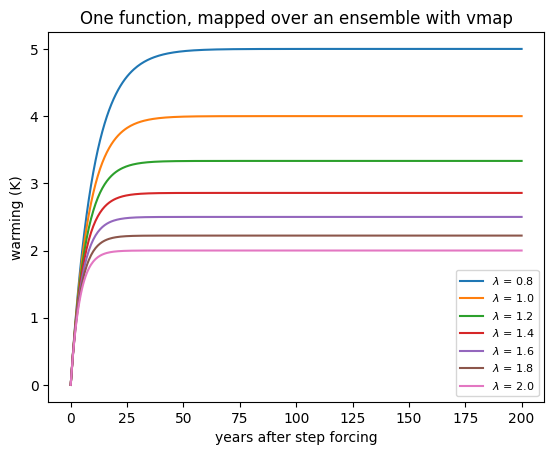

In [9]:
years = jnp.linspace(0.0, 200.0, 400)
C = 8.0                                       # heat capacity, W yr m^-2 K^-1
dF = 4.0                                      # forcing, W m^-2

def response(lam):                            # lam: feedback parameter, W m^-2 K^-1
    return dF / lam * (1.0 - jnp.exp(-lam * years / C))

lams = jnp.linspace(0.8, 2.0, 7)
ensemble = jax.vmap(response)(lams)           # shape (7, 400): one row per member

for lam, curve in zip(lams, ensemble):
    plt.plot(years, curve, label=f"$\\lambda$ = {lam:.1f}")
plt.xlabel("years after step forcing")
plt.ylabel("warming (K)")
plt.legend(fontsize=8)
plt.title("One function, mapped over an ensemble with vmap")
plt.show()

`vmap` composes with everything: `vmap` of `grad` gives per-member gradients,
`jit` of `vmap` compiles the whole ensemble. Chapter 2.1 uses `vmap` to run 60
finite-difference perturbation experiments in one call.

## Pytrees: structured parameters

Model parameters rarely live in one flat vector. JAX transformations accept *pytrees* —
nested combinations of dictionaries, lists, and tuples with arrays at the leaves — and
preserve their structure. A gradient of a function of a parameter dictionary is a
dictionary of gradients with the same keys:

In [10]:
def outgoing_longwave(params, T):
    return params["A"] + params["B"] * T       # linearized OLR, W m^-2

params = {"A": 203.3, "B": 2.09}
dOLR = jax.grad(outgoing_longwave)(params, 15.0)
print(dOLR)      # same structure as params: sensitivity to each parameter

{'A': Array(1., dtype=float64, weak_type=True), 'B': Array(15., dtype=float64, weak_type=True)}


This is how every calibration in Part 2 is organized: physical parameters stay in a
named dictionary, and `jax.grad` returns the sensitivity to each one, by name.

## Randomness with explicit keys

NumPy's random module carries hidden global state — impure by definition. JAX instead
threads randomness explicitly: a *key* determines a random draw completely, and
`jax.random.split` derives fresh, independent keys. The same key always reproduces the
same numbers, which makes ensemble experiments exactly reproducible:

In [11]:
key = jax.random.key(0)
key, subkey = jax.random.split(key)
perturbations = jax.random.normal(subkey, (5,))
print(perturbations)
print(jax.random.normal(subkey, (5,)))    # same key -> identical draw

[-1.4008841   1.432145    0.6248107   0.20048727  0.24714761]
[-1.4008841   1.432145    0.6248107   0.20048727  0.24714761]


## Recap

| Habit from NumPy/Fortran | JAX replacement |
|---|---|
| `x[i] = v` | `x = x.at[i].set(v)` |
| `if` on a data value (under `jit`) | `jnp.where`, `jax.lax.cond` |
| Python `for` over time steps | `jax.lax.scan` |
| `print` for debugging compiled code | `jax.debug.print` |
| `np.random.seed` + global draws | explicit keys, `jax.random.split` |
| mutating globals / arguments | return new values; keep functions pure |

The [gotchas appendix](../appendix/jax-gotchas.md) keeps the full list, including two we
enable by default throughout this book: double precision (`jax_enable_x64` — JAX
defaults to single precision, which Chapter 3.5 shows is not enough for gradient
verification) and NaN debugging.

**Exercises.**
1. Write a function that sets all sub-freezing values of the profile `T` to −40 °C
   using `.at[]` with a boolean mask, then do the same with `jnp.where`.
2. Use `vmap` to evaluate `response` over a grid of *both* $\lambda$ and $\Delta F$
   (hint: nest two `vmap`s).
3. Predict what `jax.jit(lambda x: print(x) or x)(3.0)` prints, then check.